# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


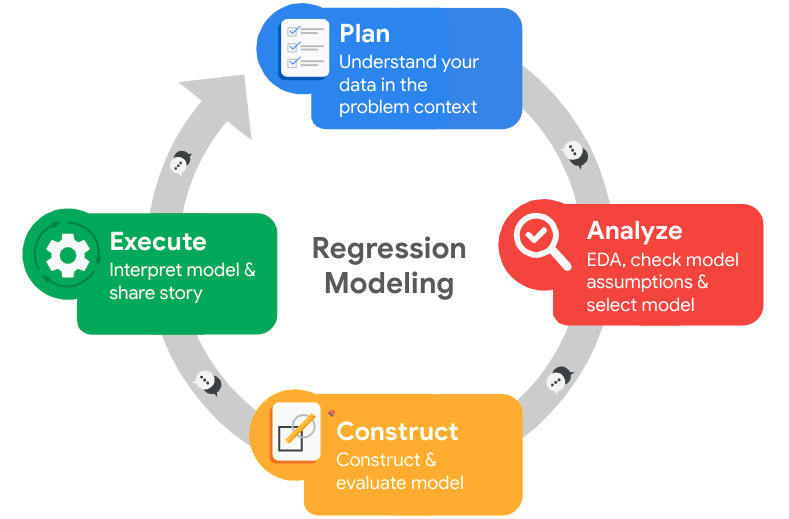

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [2]:
# Import packages
### YOUR CODE HERE ### 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [4]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [5]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [6]:
# Display all column names
### YOUR CODE HERE ###
df0.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                object
salary                    object
dtype: object

In [7]:
# Rename columns as needed
### YOUR CODE HERE ###

df0 = df0.rename(
    columns={
        "average_montly_hours": "average_monthly_hours",
        "time_spend_company": "time_spent_company",
        "Work_accident": "work_accident",
        "Department": "department",
    }
)

# Ensure all column names are lowercase
df0.columns = df0.columns.str.lower()

# Display all column names after the update
### YOUR CODE HERE ###
df0.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check missing values

Check for any missing values in the data.

In [8]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spent_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [9]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [10]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated(keep=False)]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [11]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df1 = df0.drop_duplicates()

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spent_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

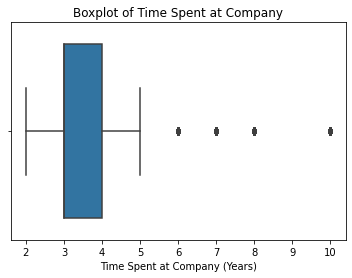

In [12]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###

plt.figure(figsize=(6, 4))
sns.boxplot(data=df1, x="time_spent_company")
plt.title("Boxplot of Time Spent at Company")
plt.xlabel("Time Spent at Company (Years)")
plt.show()

In [13]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###

# Calculate IQR for time_spent_company
percentile25 = df1["time_spent_company"].quantile(0.25)
percentile75 = df1["time_spent_company"].quantile(0.75)
iqr = percentile75 - percentile25

# Define upper and lower bounds
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Identify outliers
outliers = df1[
    (df1["time_spent_company"] > upper_limit)
    | (df1["time_spent_company"] < lower_limit)
]

# Count the number of outlier rows
print("Number of rows containing outliers:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows containing outliers: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [14]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###

stayed = df1[df1['left'] == 0]
left = df1[df1['left'] == 1]

print('People who stayed:', len(stayed))
print('People who left:', len(left))

# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###

percentages = df1['left'].value_counts(normalize=True) * 100

print(f"Percentage who stayed: {percentages[0]:.2f}%")
print(f"Percentage who left: {percentages[1]:.2f}%")

People who stayed: 10000
People who left: 1991
Percentage who stayed: 83.40%
Percentage who left: 16.60%


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

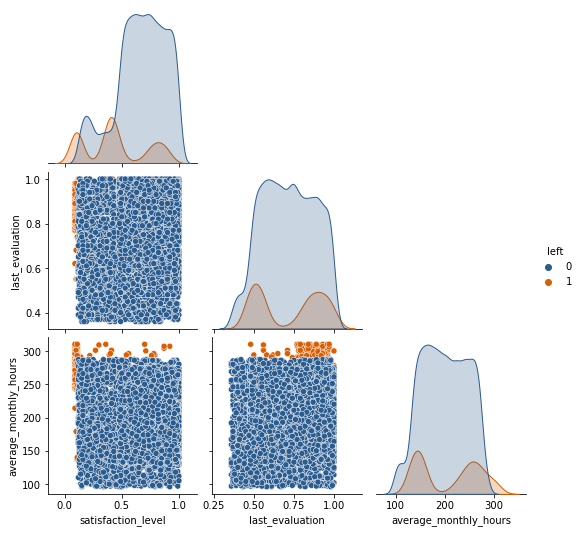

In [15]:
# Create a plot as needed
### YOUR CODE HERE ###

# Select only 3 main features + target variable 'left'
sns.pairplot(
    data=df1[['satisfaction_level', 'last_evaluation', 'average_monthly_hours', 'left']], 
    hue='left', 
    palette={0: '#2b5c8f', 1: '#d95f02'},
    corner=True
)
plt.show()

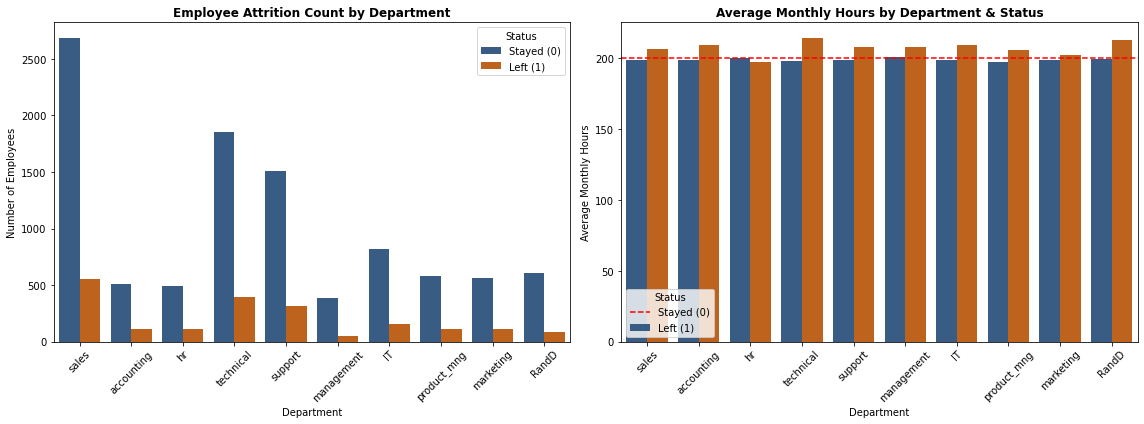

In [16]:
# Create a plot as needed
### YOUR CODE HERE ###

# Set up canvas with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Employee Turnover Count by Department
sns.countplot(
    data=df1, 
    x='department', 
    hue='left', 
    palette={0: '#2b5c8f', 1: '#d95f02'}, 
    ax=axes[0]
)
axes[0].set_title('Employee Attrition Count by Department', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Department', fontsize=10)
axes[0].set_ylabel('Number of Employees', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Status', labels=['Stayed (0)', 'Left (1)'])

# Plot 2: Average Monthly Hours vs. Department by Attrition (Burnout Check)
sns.barplot(
    data=df1, 
    x='department', 
    y='average_monthly_hours', 
    hue='left', 
    palette={0: '#2b5c8f', 1: '#d95f02'}, 
    ci=None, 
    ax=axes[1]
)
axes[1].set_title('Average Monthly Hours by Department & Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Department', fontsize=10)
axes[1].set_ylabel('Average Monthly Hours', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(200, color='red', linestyle='--', label='200 HR Threshold')
axes[1].legend(title='Status', labels=['Stayed (0)', 'Left (1)'])

plt.tight_layout()
plt.show()

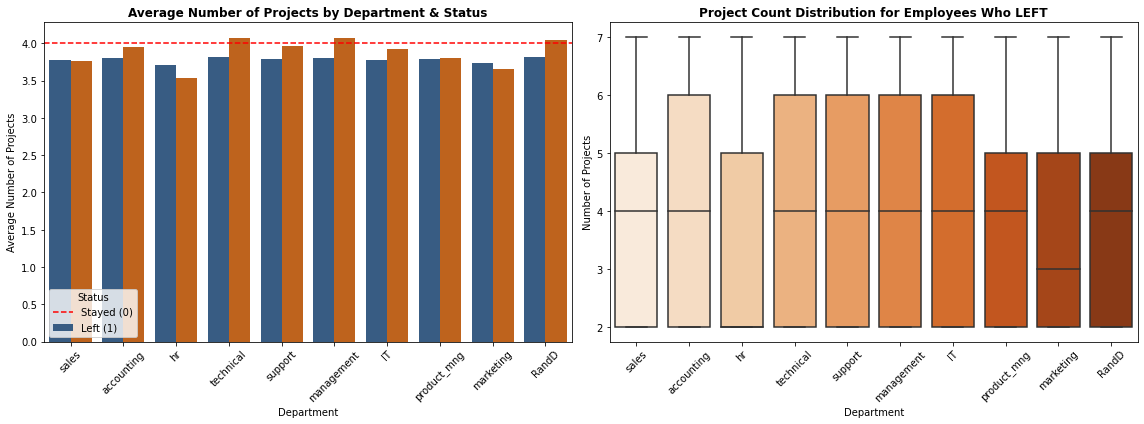

--- Average Projects per Department by Status ---
left                0         1
department                     
IT           3.771394  3.930380
RandD        3.822660  4.047059
accounting   3.808594  3.954128
hr           3.706967  3.539823
management   3.804688  4.076923
marketing    3.732620  3.660714
product_mng  3.793403  3.800000
sales        3.779844  3.763636
support      3.790590  3.967949
technical    3.814455  4.071795


In [35]:
# Create a plot as needed
### YOUR CODE HERE ###

import matplotlib.pyplot as plt
import seaborn as sns

# Set up side-by-side plots for department project workload
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Number of Projects per Department by Attrition Status
sns.barplot(
    data=df1, 
    x='department', 
    y='number_project', 
    hue='left', 
    palette={0: '#2b5c8f', 1: '#d95f02'}, 
    ci=None, 
    ax=axes[0]
)
axes[0].set_title('Average Number of Projects by Department & Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Department', fontsize=10)
axes[0].set_ylabel('Average Number of Projects', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(4.0, color='red', linestyle='--', label='Overwork Threshold (4+ Projects)')
axes[0].legend(title='Status', labels=['Stayed (0)', 'Left (1)'])

# Plot 2: Boxplot showing project distribution across departments for those who LEFT
sns.boxplot(
    data=df1[df1['left'] == 1], 
    x='department', 
    y='number_project', 
    palette='Oranges', 
    ax=axes[1]
)
axes[1].set_title('Project Count Distribution for Employees Who LEFT', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Department', fontsize=10)
axes[1].set_ylabel('Number of Projects', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print average projects per department by status
print("--- Average Projects per Department by Status ---")
print(df1.groupby(['department', 'left'])['number_project'].mean().unstack())

### Insights


### Key Findings & Insights

#### 1. Main Causes of Employee Turnover

* **Key Drivers:** Employee satisfaction level (`satisfaction_level`) and monthly working hours (`average_monthly_hours`) are the two primary factors deciding whether an employee stays or leaves.



#### 2. Why Employees Leave

* **Low Satisfaction:** Employees with low satisfaction scores ($0.1$ to $0.4$) have extremely high turnover rates.


* **Burnout from Long Hours:** Employees working $280$ to $300+$ hours per month leave due to severe burnout.


* **Two Main Groups Leave:** The data clearly splits departing employees into two groups: disengaged low-performers and overworked top-performers.



#### 3. Department Breakdown (Hours & Departures)

* **Highest Exit Counts:** **Sales**, **Technical**, and **Support** have the largest number of employees leaving, mainly due to having larger total team sizes.


* **Overtime Across All Teams:** In almost every department, employees who left consistently worked **over 200 hours per month**, which is significantly higher than those who stayed.



#### 4. Project Workload & Overworked Teams

* **Too Few or Too Many Projects:** Turnover is highest at two extremes: employees with only **2 projects** (underutilized) and those with **6–7 projects** (overloaded). Almost 100% of employees assigned to 7 projects left the company.


* **The Sweet Spot:** Employees assigned **3 to 5 projects** are the most stable and least likely to leave.


* **Most Overworked Departments:** **Technical**, **Management**, **R&D**, and **Accounting** assign the highest average number of projects to employees who end up leaving.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



### Constructing Stage Reflection

* **Do you notice anything odd?**
  There was some class imbalance because fewer employees left than stayed.

* **Which independent variables did you choose and why?**
  I used variables such as **satisfaction level, number of projects, time spent at the company, and average monthly hours** because they were important predictors of employee turnover.

* **Are each of the assumptions met?**
  The main assumptions were checked, and the data was suitable for building the model.

* **How well does your model fit the data?**
  The Random Forest model performed very well, with about **99% accuracy** and strong overall performance.

* **Can you improve it?**
  Yes. I could improve it by **tuning hyperparameters, testing other models, and using cross-validation**.

* **What resources do you use?**

  * [Python Documentation](https://docs.python.org/3/?utm_source=chatgpt.com)
  * [pandas Documentation](https://pandas.pydata.org/docs/?utm_source=chatgpt.com)
  * [scikit-learn Documentation](https://scikit-learn.org/stable/?utm_source=chatgpt.com)

* **Ethical considerations:**
  Employee information should remain **private**, and predictions should not be used to unfairly judge or penalize employees.


## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

Based on the target variable (`left`), this is a **Binary Classification** task.

* **Target Variable:** `left`
* **Possible Outcomes:** Two discrete categories — `0` (Employee Stayed) or `1` (Employee Left).
* **Objective:** Predict the probability or class membership of an instance belonging to one of two distinct categories.

### Identify the types of models most appropriate for this task.

### Model Selection:

* **Best Fit Model (Random Forest):** Because the relationships between these features and turnover are non-linear and contain distinct sub-groups/clusters, a tree-based ensemble model like **Random Forest** is ideal. It handles non-linear decision boundaries and complex feature interactions without requiring strict distributional assumptions.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [23]:
### YOUR CODE HERE ###

y = df1['left']

X = df1.drop('left', axis=1)

In [24]:
# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [25]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

In [26]:
# 1. Instantiate the model
rf = RandomForestClassifier(random_state=0)

# 2. Fit (train) the model on the training data
rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0,
                       warm_start=False)

In [27]:
# Predict on the unseen test data
y_pred = rf.predict(X_test)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2001
           1       0.99      0.91      0.95       398

    accuracy                           0.98      2399
   macro avg       0.99      0.95      0.97      2399
weighted avg       0.98      0.98      0.98      2399



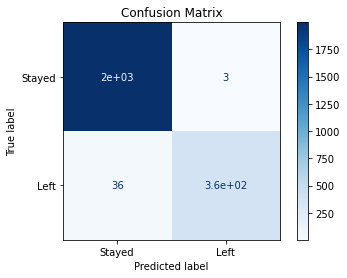

In [28]:
# Print Precision, Recall, F1-Score
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [29]:
# Verify all columns are numeric
print(X.dtypes)

satisfaction_level        float64
last_evaluation           float64
number_project              int64
average_monthly_hours       int64
time_spent_company          int64
work_accident               int64
promotion_last_5years       int64
department_RandD            uint8
department_accounting       uint8
department_hr               uint8
department_management       uint8
department_marketing        uint8
department_product_mng      uint8
department_sales            uint8
department_support          uint8
department_technical        uint8
salary_low                  uint8
salary_medium               uint8
dtype: object


In [30]:
# Check class proportions
print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train target distribution:
0    0.833924
1    0.166076
Name: left, dtype: float64

Test target distribution:
0    0.834098
1    0.165902
Name: left, dtype: float64


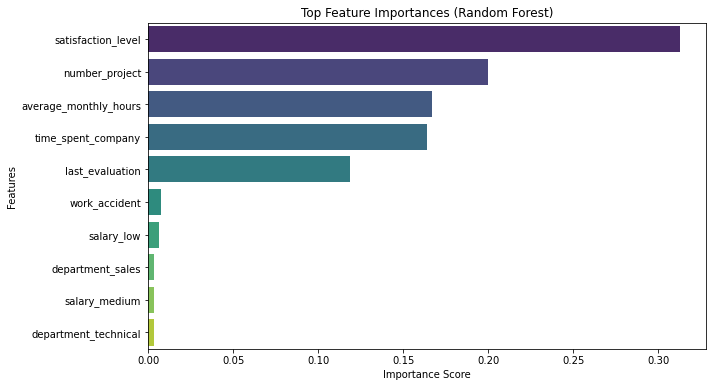

In [31]:
# Extract feature importances from the Random Forest model
importances = rf.feature_importances_
feature_names = X.columns

# Create and sort a DataFrame
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot the top features
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [32]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

CV scores: [0.98436686 0.98228244 0.9822732  0.98540146 0.98383733]
Mean CV accuracy: 0.9836322576333151


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



### 1. What key insights emerged from your model(s)?

The model showed that **satisfaction level, number of projects, time spent at the company, and average monthly hours** were important factors in predicting employee turnover.

### 2. What business recommendations do you propose?

Salifort Motors should focus on **employee satisfaction, workload, and working hours** to help reduce employee turnover.

### 3. What recommendations would you make to your manager/company?

Use the model as an **early-warning tool** to identify employees who may be at risk of leaving and investigate their needs.

### 4. Could your model be improved?

Yes. It could be improved by **tuning the model, testing other algorithms, and using cross-validation** to make sure it performs well on new data.

### 5. What other questions could you address?

* What factors have the biggest impact on turnover?
* Does workload increase the chance of leaving?
* Which employee groups have the highest turnover?

### 6. What resources did you use?

* [Python Documentation](https://docs.python.org/3/?utm_source=chatgpt.com)
* [pandas Documentation](https://pandas.pydata.org/docs/?utm_source=chatgpt.com)
* [Scikit-learn Documentation](https://scikit-learn.org/stable/?utm_source=chatgpt.com)
* Google Advanced Data Analytics course materials.

### 7. Ethical considerations?

Employee data should be kept **private**, and model predictions should support decisions rather than automatically determine how employees are treated.


## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The Random Forest model achieved a mean cross-validation accuracy of 98.36%. The similar scores across all five folds indicate that the model is stable and performs consistently on different subsets of the data. The model identified satisfaction level, number of projects, time spent at the company, and average monthly hours as the most important factors in predicting employee turnover. The model can help Salifort Motors identify employees at higher risk of leaving and better understand the factors related to turnover.

### Conclusion, Recommendations, Next Steps

Conclusion: The model showed that employee satisfaction, workload, and time at the company are important factors related to turnover.

Recommendations: Salifort Motors should focus on improving employee satisfaction, managing workloads, and monitoring working hours.

Next Steps: Use the model as an early-warning tool, continue collecting employee data, and test the model regularly to improve its performance.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.